# AgriEdge — Research Benchmark Suite

Paper-ready statistics, benchmarks, ablations and figures for the AgriEdge India v1 classifier +
SmolLM2-360M SLM. Fresh environment — reloads everything from the two Hugging Face repos already
pushed (`agriedge-classifier`, `agriedge-slm`); no local state assumed.

**Honesty note on the test split:** the India v1 classifier was trained with a single 90/10
train/held-out split (seed 42), not a train/val/test three-way split. Re-splitting the same pool
into a fresh "test set" now risks leakage against what the model already saw during training. So
this notebook reuses the **original held-out 10% split** (genuinely never trained on) as the test
set, rather than fabricating a new split that would silently leak. Tables below are Train / Test /
Total, not Train / Val / Test — reflecting what's actually true rather than what would look tidier.


In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "sympy>=1.13"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '-U', 'sympy>=1.13'], returncode=0)

In [2]:
# =====================================================================
# CELL 1 — Config, hardware check, installs.
# =====================================================================
import os, subprocess, sys, importlib, json, time

HF_TOKEN = "hf token"   # <-- hardcode your token here

CLF_REPO = "vedantjadhav701/agriedge-classifier"
SLM_REPO = "vedantjadhav701/agriedge-slm"
CROPS_DATASET_REPO = "vedantjadhav701/agriedge-india-crops"   # already-built dataset — no need to re-derive from AgML

VISION_MODEL_ID = "google/siglip-base-patch16-224"
LM_MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

PROJECT_ROOT = "/kaggle/working/agriedge_bench"
IMAGE_ROOT = f"{PROJECT_ROOT}/datasets_sorted"
EXPORT_DIR = f"{PROJECT_ROOT}/export"
RESULTS_DIR = f"{PROJECT_ROOT}/results"
FIG_DIR = f"{PROJECT_ROOT}/figures"
LLAMA_CPP_DIR = f"{PROJECT_ROOT}/llama.cpp"

for d in [PROJECT_ROOT, IMAGE_ROOT, EXPORT_DIR, RESULTS_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# same 18 India-relevant AgML datasets used to train the India v1 classifier
INDIA_DATASETS = {
    "paddy_disease_classification": "rice",
    "rice_leaf_disease_classification": "rice",
    "corn_maize_leaf_disease": "maize",
    "blackgram_plant_leaf_disease_classification": "black_gram",
    "tomato_leaf_disease": "tomato",
    "chilli_leaf_classification": "chilli",
    "onion_leaf_classification": "onion",
    "cucumber_disease_classification": "cucumber",
    "sunflower_disease_classification": "sunflower",
    "banana_leaf_disease_classification": "banana",
    "papaya_leaf_disease_classification": "papaya",
    "guava_disease_pakistan": "guava",
    "orange_leaf_disease_classification": "orange",
    "java_plum_leaf_disease_classification": "jamun",
    "coconut_tree_disease_classification": "coconut",
    "tea_leaf_disease_classification": "tea",
    "arabica_coffee_leaf_disease_classification": "coffee",
    "betel_leaf_disease_classification": "betel_leaf",
}
MAX_PER_CLASS = 300
MIN_PER_CLASS = 5
VAL_FRAC = 0.15
SPLIT_SEED = 42

def _ver(pkg):
    try:
        return getattr(importlib.import_module(pkg), "__version__", "unknown")
    except ImportError:
        return None

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    g = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {g.name} — {g.total_memory/1024**3:.1f} GB")

REQUIRED = {"transformers": "4.45.0", "timm": "1.0.0", "onnx": "1.16.0", "onnxruntime": "1.18.0",
            "onnxconverter-common": "1.14.0", "scikit-learn": "1.3.0", "matplotlib": "3.7.0",
            "huggingface_hub": "0.24.0", "agml": "0.1.0"}
IMPORT_OVERRIDES = {"scikit-learn": "sklearn", "onnxconverter-common": "onnxconverter_common"}
to_install = [pkg for pkg, v in REQUIRED.items() if _ver(IMPORT_OVERRIDES.get(pkg, pkg)) is None]
if to_install:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *to_install], check=True)
print("Installs OK." if not to_install else f"Installed: {to_install}")


torch: 2.10.0+cu128 | CUDA: True | GPUs: 2
  GPU 0: Tesla T4 — 14.6 GB
  GPU 1: Tesla T4 — 14.6 GB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.7/778.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 21.7 MB/s eta 0:00:00
Installed: ['onnxruntime', 'onnxconverter-common', 'agml']


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.39.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 which is incompatible.


In [3]:
# =====================================================================
# CELL 2 — Load the already-built dataset from the Hub instead of
# re-deriving it from AgML. The `validation` split here is ~15% of
# total (matches VAL_FRAC=0.15 used when the India v1 checkpoint was
# trained) — same held-out split, just properly packaged this time.
# =====================================================================
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from PIL import Image
import json as _json

ds = load_dataset(CROPS_DATASET_REPO, token=HF_TOKEN)
print("Splits:", {k: len(v) for k, v in ds.items()})
print("Features:", ds[list(ds.keys())[0]].features)

labels_path = hf_hub_download(CROPS_DATASET_REPO, "labels.json", repo_type="dataset", token=HF_TOKEN)
with open(labels_path) as f:
    labels_meta = _json.load(f)
print("\nlabels.json top-level keys:", list(labels_meta.keys()) if isinstance(labels_meta, dict) else f"(list, {len(labels_meta)} entries)")

# --- auto-detect column names (printed above tells you if these guesses are wrong) ---
sample = ds[list(ds.keys())[0]][0]
IMAGE_COL = next((c for c in ["image", "img", "picture"] if c in sample), None)
CROP_COL = next((c for c in ["crop", "crop_name"] if c in sample), None)
DISEASE_COL = next((c for c in ["disease", "condition"] if c in sample), None)
LABEL_COL = next((c for c in ["label", "crop_condition", "class"] if c in sample), None)
assert IMAGE_COL and (LABEL_COL or (CROP_COL and DISEASE_COL)), (
    f"Couldn't auto-detect columns from sample keys {list(sample.keys())} — "
    f"update IMAGE_COL/CROP_COL/DISEASE_COL/LABEL_COL by hand from the printed Features above."
)
print(f"\nUsing IMAGE_COL={IMAGE_COL!r}  CROP_COL={CROP_COL!r}  DISEASE_COL={DISEASE_COL!r}  LABEL_COL={LABEL_COL!r}")

# label decoding: HF ClassLabel stores ints, need the string back
def _decode_label_field(split_ds, col):
    feat = split_ds.features.get(col)
    if feat is not None and hasattr(feat, "int2str"):
        return feat.int2str
    return lambda x: x   # already a string

# --- materialize images to disk once, rebuild india_records in the same shape used everywhere else ---
india_records = []
SPLIT_NAME_MAP = {"train": "train", "validation": "test", "test": "test"}   # this repo's "validation" IS our held-out test
for hf_split, our_split in SPLIT_NAME_MAP.items():
    if hf_split not in ds:
        continue
    split_ds = ds[hf_split]
    crop_decoder = _decode_label_field(split_ds, CROP_COL) if CROP_COL else None
    disease_decoder = _decode_label_field(split_ds, DISEASE_COL) if DISEASE_COL else None
    label_decoder = _decode_label_field(split_ds, LABEL_COL) if LABEL_COL else None
    split_dir = os.path.join(IMAGE_ROOT, hf_split)
    os.makedirs(split_dir, exist_ok=True)
    for i, row in enumerate(split_ds):
        img = row[IMAGE_COL]
        if not isinstance(img, Image.Image):
            continue
        out_path = os.path.join(split_dir, f"{i:06d}.jpg")
        if not os.path.exists(out_path):
            img.convert("RGB").save(out_path, quality=92)

        if LABEL_COL:
            raw = row[LABEL_COL]
            label = label_decoder(raw) if label_decoder else raw
            crop, disease = label.split("__", 1) if "__" in label else (label, "unknown")
        else:
            raw_crop, raw_disease = row[CROP_COL], row[DISEASE_COL]
            crop = crop_decoder(raw_crop) if crop_decoder else raw_crop
            disease = disease_decoder(raw_disease) if disease_decoder else raw_disease
            label = f"{crop}__{disease}"

        india_records.append({"path": out_path, "dataset": hf_split, "crop": crop,
                              "disease": disease, "label": label, "split": our_split})

label_list = sorted({r["label"] for r in india_records})
label_to_idx = {l: i for i, l in enumerate(label_list)}
crop_list = sorted({r["crop"] for r in india_records})

train_recs = [r for r in india_records if r["split"] == "train"]
test_recs = [r for r in india_records if r["split"] == "test"]

print(f"\nTotal: {len(india_records)}  Train: {len(train_recs)}  Test (held-out): {len(test_recs)}")
print(f"Crops: {len(crop_list)}  crop__condition classes: {len(label_list)}")


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/263M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/182M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25373 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4476 [00:00<?, ? examples/s]

Splits: {'train': 25373, 'validation': 4476}
Features: {'image': Image(mode=None, decode=True), 'crop': Value('string'), 'disease': Value('string'), 'label': Value('string'), 'dataset': Value('string')}


labels.json: 0.00B [00:00, ?B/s]


labels.json top-level keys: ['labels', 'crops', 'source_datasets', 'max_side']

Using IMAGE_COL='image'  CROP_COL='crop'  DISEASE_COL='disease'  LABEL_COL='label'

Total: 29849  Train: 25373  Test (held-out): 4476
Crops: 17  crop__condition classes: 103


Split         Images   Crops  Conditions
Train          25373      17         103
Test            4476      17         103
Total          29849      17         103

Class size — min: 70  median: 300  max: 600  imbalance ratio (max/min): 8.6x


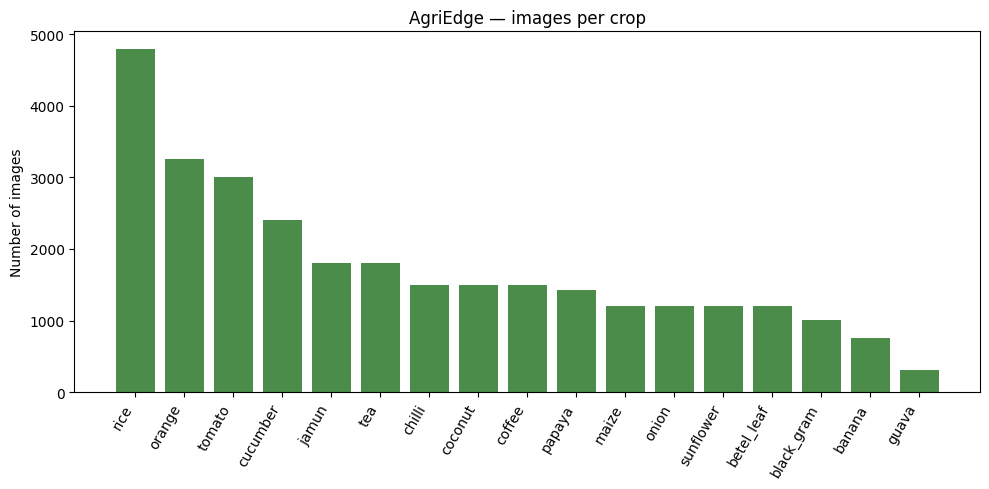

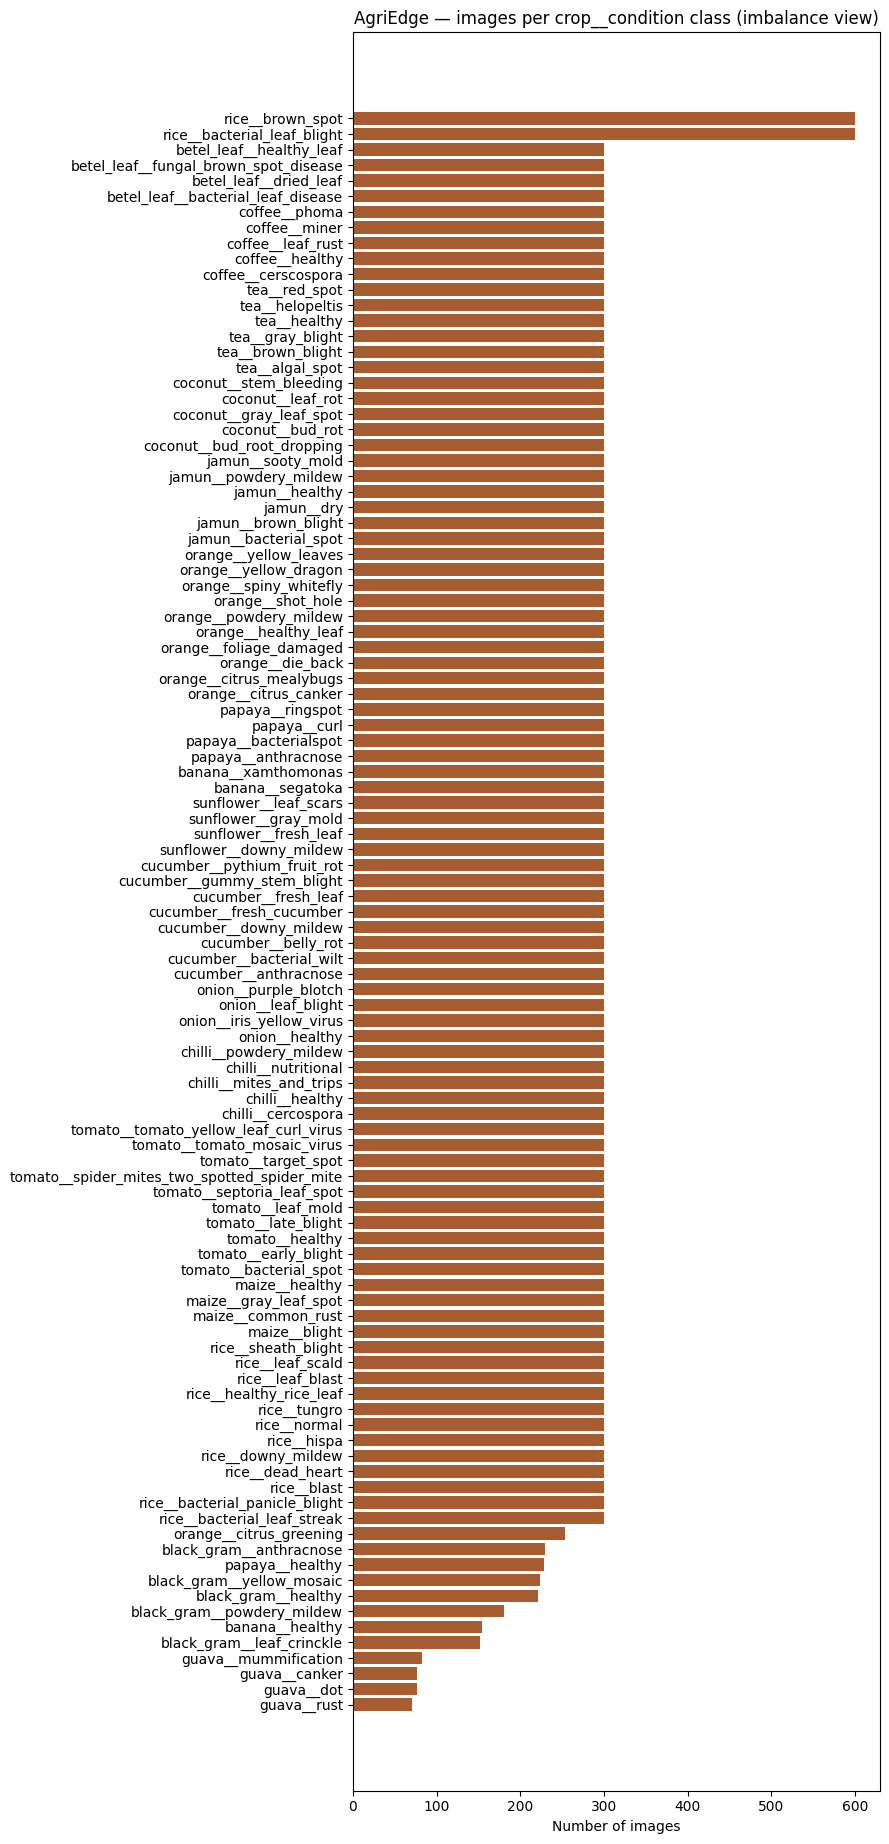


Saved: fig_dataset_crop_distribution.png, fig_dataset_condition_distribution.png, table1_dataset_statistics.csv


In [5]:
# =====================================================================
# CELL 3 — TABLE 1: dataset statistics, + crop/condition distribution figures.
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import csv
from collections import Counter

def summarize(recs, name):
    n = len(recs)
    crops = len({r["crop"] for r in recs})
    conds = len({r["label"] for r in recs})
    return {"Split": name, "Images": n, "Crops": crops, "Conditions": conds}

table1_rows = [summarize(train_recs, "Train"), summarize(test_recs, "Test"), summarize(india_records, "Total")]
print(f"{'Split':<10}{'Images':>10}{'Crops':>8}{'Conditions':>12}")
for row in table1_rows:
    print(f"{row['Split']:<10}{row['Images']:>10}{row['Crops']:>8}{row['Conditions']:>12}")

with open(f"{RESULTS_DIR}/table1_dataset_statistics.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["Split", "Images", "Crops", "Conditions"])
    writer.writeheader()
    writer.writerows(table1_rows)

class_sizes = Counter(r["label"] for r in india_records)
sizes = sorted(class_sizes.values())
imbalance_ratio = max(sizes) / min(sizes)
print(f"\nClass size — min: {min(sizes)}  median: {int(np.median(sizes))}  max: {max(sizes)}  "
      f"imbalance ratio (max/min): {imbalance_ratio:.1f}x")

crop_counts = Counter(r["crop"] for r in india_records)
fig, ax = plt.subplots(figsize=(10, 5))
crops_sorted = sorted(crop_counts.items(), key=lambda x: -x[1])
ax.bar([c for c, _ in crops_sorted], [n for _, n in crops_sorted], color="#4c8c4a")
ax.set_ylabel("Number of images")
ax.set_title("AgriEdge — images per crop")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_dataset_crop_distribution.png", dpi=150)
plt.show()

cond_counts = Counter(r["label"] for r in india_records)
conds_sorted = sorted(cond_counts.items(), key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(9, max(10, len(conds_sorted) * 0.18)))
ax.barh([c for c, _ in conds_sorted], [n for _, n in conds_sorted], color="#a85c32")
ax.set_xlabel("Number of images")
ax.set_title("AgriEdge — images per crop__condition class (imbalance view)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_dataset_condition_distribution.png", dpi=150)
plt.show()
print("\nSaved: fig_dataset_crop_distribution.png, fig_dataset_condition_distribution.png, table1_dataset_statistics.csv")

In [6]:
# =====================================================================
# CELL 4 — Load India v1 classifier. Only "latest.pt" exists (checkpointed
# every epoch, not best-tracked) — but its own training log showed val_acc
# still rising at the final epoch (0.893 -> 0.916 -> 0.915 -> 0.928), so
# the last epoch IS the best epoch here. Verified below, not assumed.
# =====================================================================
import torch.nn as nn
from transformers import SiglipVisionModel, AutoImageProcessor
from huggingface_hub import hf_hub_download

vision_processor = AutoImageProcessor.from_pretrained(VISION_MODEL_ID)
vision_backbone = SiglipVisionModel.from_pretrained(VISION_MODEL_ID, torch_dtype=torch.float32).cuda()

class IndiaClassifier(nn.Module):
    def __init__(self, backbone, hidden_dim, n_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(hidden_dim, n_classes)

    def forward(self, pixel_values):
        pooled = self.backbone(pixel_values=pixel_values).pooler_output
        return self.head(pooled)

ckpt_path = hf_hub_download(CLF_REPO, "india_v1_checkpoint.pt", token=HF_TOKEN)
ckpt = torch.load(ckpt_path, map_location="cuda")
assert ckpt["label_list"] == label_list, "Label ordering mismatch between checkpoint and rebuilt dataset — do not proceed until this matches."

classifier = IndiaClassifier(vision_backbone, vision_backbone.config.hidden_size, len(label_list)).cuda()
classifier.load_state_dict(ckpt["model_state"])
classifier.eval()

print(f"Loaded checkpoint: {ckpt_path}")
print(f"Epoch: {ckpt['epoch']}  (final epoch of training — no earlier checkpoint was retained to compare against)")
print(f"{sum(p.numel() for p in classifier.parameters())/1e6:.1f}M total params")


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight         

india_v1_checkpoint.pt:   0%|          | 0.00/486M [00:00<?, ?B/s]

Loaded checkpoint: /root/.cache/huggingface/hub/models--vedantjadhav701--agriedge-classifier/snapshots/9ae7ea52125aac0d4ea2bff241e794f922750a42/india_v1_checkpoint.pt
Epoch: 3  (final epoch of training — no earlier checkpoint was retained to compare against)
93.0M total params


TABLE — classifier test-set metrics (crop__condition, 103-way)
Accuracy        0.9247
Top-5 accuracy  0.9978
Macro Precision 0.9226
Macro Recall    0.9171
Macro F1        0.9152
Weighted F1     0.9236


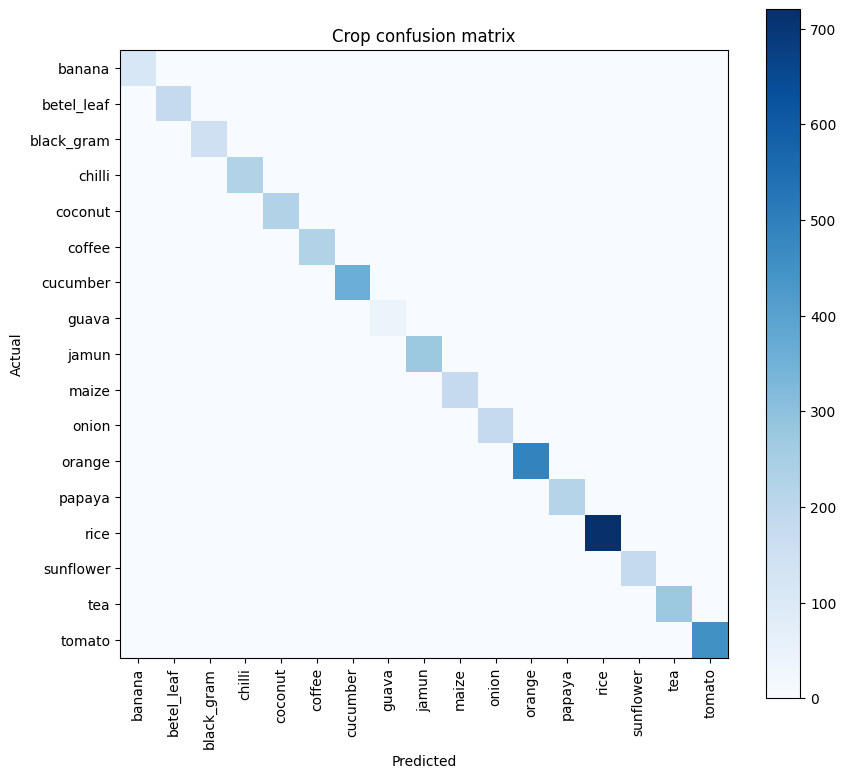

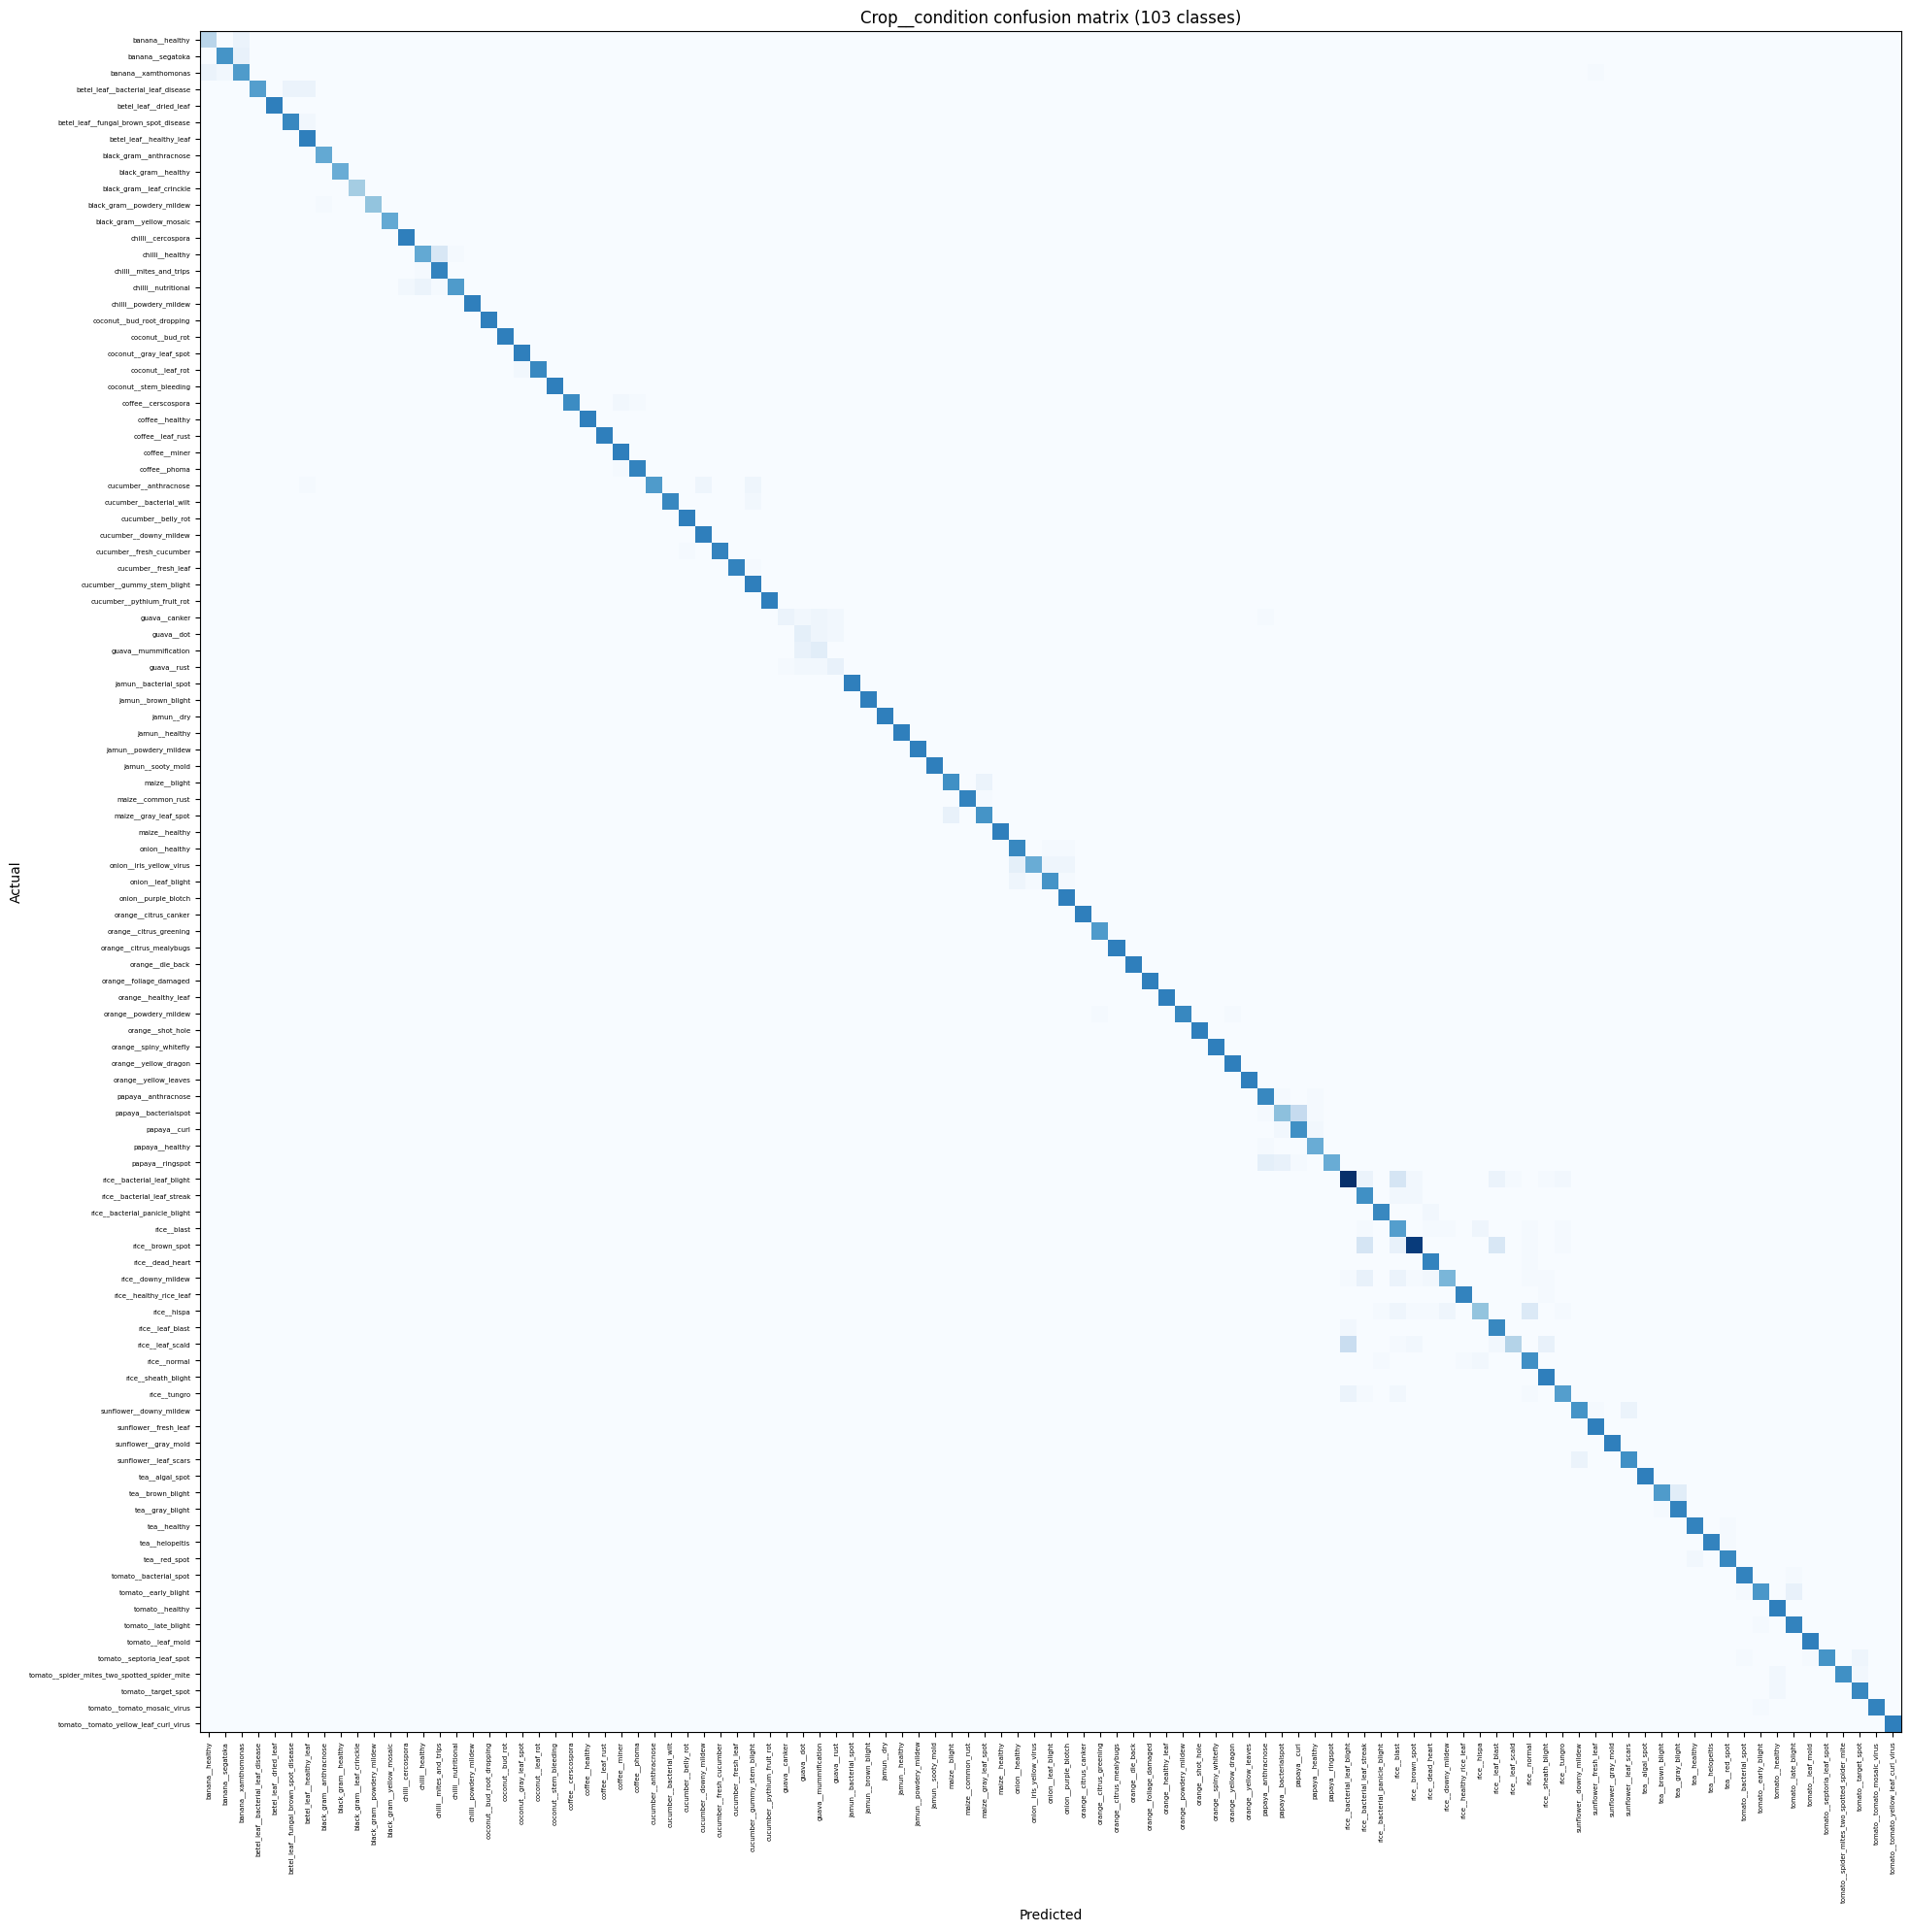


Worst 10 classes by F1:
  guava__dot                                    F1=0.462  support=11
  guava__canker                                 F1=0.471  support=12
  guava__mummification                          F1=0.519  support=12
  guava__rust                                   F1=0.526  support=10
  rice__leaf_scald                              F1=0.606  support=45
  rice__blast                                   F1=0.673  support=45
  papaya__bacterialspot                         F1=0.675  support=45
  rice__hispa                                   F1=0.684  support=45
  rice__bacterial_leaf_blight                   F1=0.734  support=90
  rice__bacterial_leaf_streak                   F1=0.759  support=45

Best 10 classes by F1:
  orange__citrus_mealybugs                      F1=1.000  support=45
  orange__die_back                              F1=1.000  support=45
  orange__foliage_damaged                       F1=1.000  support=45
  orange__healthy_leaf                          F1=1.0

In [7]:
# =====================================================================
# CELL 5 — Full test-set evaluation: accuracy/macro-F1/weighted-F1/top-5,
# crop + condition confusion matrices, per-class precision/recall/F1.
# One forward pass over the test set, everything computed from it.
# =====================================================================
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, top_k_accuracy_score,
                              confusion_matrix, classification_report)

@torch.no_grad()
def run_test_inference(records, bs=32):
    all_logits, all_labels = [], []
    for i in range(0, len(records), bs):
        chunk = records[i:i + bs]
        imgs = [Image.open(r["path"]).convert("RGB") for r in chunk]
        pv = vision_processor(images=imgs, return_tensors="pt")["pixel_values"].cuda()
        logits = classifier(pv)
        all_logits.append(logits.cpu())
        all_labels.extend([label_to_idx[r["label"]] for r in chunk])
    return torch.cat(all_logits).numpy(), np.array(all_labels)

logits, y_true = run_test_inference(test_recs)
y_pred = logits.argmax(-1)

acc = accuracy_score(y_true, y_pred)
top5 = top_k_accuracy_score(y_true, logits, k=5, labels=list(range(len(label_list))))
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
_, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print("TABLE — classifier test-set metrics (crop__condition, 103-way)")
print(f"{'Accuracy':<16}{acc:.4f}")
print(f"{'Top-5 accuracy':<16}{top5:.4f}")
print(f"{'Macro Precision':<16}{prec_macro:.4f}")
print(f"{'Macro Recall':<16}{rec_macro:.4f}")
print(f"{'Macro F1':<16}{f1_macro:.4f}")
print(f"{'Weighted F1':<16}{f1_weighted:.4f}")

with open(f"{RESULTS_DIR}/table_classifier_metrics.csv", "w") as f:
    f.write("metric,value\n")
    for k, v in [("accuracy", acc), ("top5_accuracy", top5), ("macro_precision", prec_macro),
                 ("macro_recall", rec_macro), ("macro_f1", f1_macro), ("weighted_f1", f1_weighted)]:
        f.write(f"{k},{v:.4f}\n")

# --- crop-level confusion matrix (roll up crop__condition predictions to crop) ---
label_to_crop = {i: l.split("__")[0] for i, l in enumerate(label_list)}
crop_to_idx2 = {c: i for i, c in enumerate(crop_list)}
y_true_crop = np.array([crop_to_idx2[label_to_crop[y]] for y in y_true])
y_pred_crop = np.array([crop_to_idx2[label_to_crop[y]] for y in y_pred])
cm_crop = confusion_matrix(y_true_crop, y_pred_crop, labels=list(range(len(crop_list))))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_crop, cmap="Blues")
ax.set_xticks(range(len(crop_list))); ax.set_xticklabels(crop_list, rotation=90)
ax.set_yticks(range(len(crop_list))); ax.set_yticklabels(crop_list)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Crop confusion matrix")
plt.colorbar(im); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_confusion_crop.png", dpi=150)
plt.show()

# --- condition (103-class) confusion matrix — large figure, sparse annotation ---
cm_cond = confusion_matrix(y_true, y_pred, labels=list(range(len(label_list))))
fig, ax = plt.subplots(figsize=(22, 20))
im = ax.imshow(cm_cond, cmap="Blues")
ax.set_xticks(range(len(label_list))); ax.set_xticklabels(label_list, rotation=90, fontsize=5)
ax.set_yticks(range(len(label_list))); ax.set_yticklabels(label_list, fontsize=5)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Crop__condition confusion matrix (103 classes)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_confusion_condition.png", dpi=150)
plt.show()

# --- per-class precision/recall/F1 ---
report = classification_report(y_true, y_pred, target_names=label_list, output_dict=True, zero_division=0)
per_class_rows = [{"class": k, "precision": v["precision"], "recall": v["recall"], "f1": v["f1-score"], "support": v["support"]}
                   for k, v in report.items() if k in label_list]
with open(f"{RESULTS_DIR}/table_per_class_metrics.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["class", "precision", "recall", "f1", "support"])
    writer.writeheader()
    writer.writerows(per_class_rows)

per_class_sorted = sorted(per_class_rows, key=lambda r: r["f1"])
print("\nWorst 10 classes by F1:")
for r in per_class_sorted[:10]:
    print(f"  {r['class']:<45} F1={r['f1']:.3f}  support={int(r['support'])}")
print("\nBest 10 classes by F1:")
for r in per_class_sorted[-10:]:
    print(f"  {r['class']:<45} F1={r['f1']:.3f}  support={int(r['support'])}")
rare = [r for r in per_class_rows if r["support"] < 10]
print(f"\nRare classes (support < 10): {len(rare)} — these F1 numbers are noisy, treat with caution.")

print("\nSaved: table_classifier_metrics.csv, table_per_class_metrics.csv, fig_confusion_crop.png, fig_confusion_condition.png")


In [9]:
# =====================================================================
# CELL 6 — Export FP16 ONNX (new — only fp32/int8 existed before),
# then model-size + CPU latency benchmark across FP32/FP16/INT8.
# FIXED: keep_io_types=True left an FP32 input feeding an FP16 Conv
# (ORT load error). FP16 model now uses FP16 I/O, converted with
# validated fallbacks. Matches Cell 9's dtype=np.float16 usage.
# =====================================================================
import warnings
import onnx, onnxruntime as ort
from onnxconverter_common import float16 as onnx_float16
from onnxruntime.quantization import quantize_dynamic, QuantType

FP32_PATH = f"{EXPORT_DIR}/clf_fp32.onnx"
FP16_PATH = f"{EXPORT_DIR}/clf_fp16.onnx"
INT8_PATH = f"{EXPORT_DIR}/clf_int8.onnx"

# ---------- helpers ----------
def preprocess_np(images):
    return vision_processor(images=images, return_tensors="pt")["pixel_values"].numpy().astype(np.float32)

def _session(path):
    return ort.InferenceSession(path, providers=["CPUExecutionProvider"])

def _input_dtype(sess):
    return np.float16 if "float16" in sess.get_inputs()[0].type else np.float32

# ---------- FP32 export (skipped if already on disk) ----------
classifier.eval()
if not os.path.exists(FP32_PATH):
    dummy = torch.randn(1, 3, 224, 224, dtype=torch.float32).cuda()
    torch.onnx.export(classifier, dummy, FP32_PATH, input_names=["pixel_values"], output_names=["logits"],
                       dynamic_axes={"pixel_values": {0: "batch"}, "logits": {0: "batch"}},
                       opset_version=17, dynamo=False)

# ---------- FP16 conversion: try converters in order, validate each ----------
def _fp16_common(path):
    m = onnx.load(path)
    del m.graph.value_info[:]          # drop stale FP32 type annotations from the exporter
    return onnx_float16.convert_float_to_float16(m, keep_io_types=False)

def _fp16_ort(path):
    from onnxruntime.transformers.float16 import convert_float_to_float16 as ort_fp16
    return ort_fp16(onnx.load(path), keep_io_types=False)

def _fp16_conv_fp32(path):             # last resort: keep Conv nodes in FP32
    m = onnx.load(path)
    del m.graph.value_info[:]
    block = [n.name for n in m.graph.node if n.op_type == "Conv"]
    return onnx_float16.convert_float_to_float16(m, keep_io_types=False, node_block_list=block)

sample_x = preprocess_np([Image.open(test_recs[0]["path"]).convert("RGB")])
ref_logits = _session(FP32_PATH).run(None, {"pixel_values": sample_x})[0]

FP16_METHOD = None
for name, fn in [("onnxconverter_common", _fp16_common),
                 ("onnxruntime.transformers", _fp16_ort),
                 ("onnxconverter_common (Conv kept FP32)", _fp16_conv_fp32)]:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")      # silences the "will be truncated to 1e-07" spam
            m16 = fn(FP32_PATH)
        onnx.save(m16, FP16_PATH)
        s16 = _session(FP16_PATH)                # this is where the original error was raised
        out = s16.run(None, {"pixel_values": sample_x.astype(_input_dtype(s16))})[0].astype(np.float32)
        assert np.isfinite(out).all(), "NaN/inf in FP16 output"
        FP16_METHOD = name
        print(f"FP16 export OK via {name} | max|logit diff| vs FP32 = {np.abs(out - ref_logits).max():.4f} "
              f"| top-1 matches FP32: {out.argmax(-1)[0] == ref_logits.argmax(-1)[0]}")
        break
    except Exception as e:
        print(f"FP16 via {name} failed: {str(e)[:160]}")
if FP16_METHOD is None:
    raise RuntimeError("All FP16 conversion routes failed — see messages above.")

# ---------- INT8 dynamic quantization (skipped if already on disk) ----------
if not os.path.exists(INT8_PATH):
    try:
        quantize_dynamic(FP32_PATH, INT8_PATH, weight_type=QuantType.QInt8, per_channel=True)
    except Exception as e:
        print("quantize_dynamic note:", str(e)[:150])

# ---------- sizes ----------
pt_size_mb = os.path.getsize(ckpt_path) / 1e6
size_rows = [("PyTorch checkpoint (.pt)", pt_size_mb),
             ("FP32 ONNX", os.path.getsize(FP32_PATH) / 1e6),
             ("FP16 ONNX", os.path.getsize(FP16_PATH) / 1e6),
             ("INT8 ONNX", os.path.getsize(INT8_PATH) / 1e6)]
print(f"\n{'Model':<28}{'Size (MB)':>12}")
for name, sz in size_rows:
    print(f"{name:<28}{sz:>12.1f}")

# ---------- latency ----------
def latency_bench(path, n=100, providers=("CPUExecutionProvider",)):
    sess = ort.InferenceSession(path, providers=list(providers))
    x = sample_x.astype(_input_dtype(sess))      # dtype read from the model, not guessed from the filename
    for _ in range(10):
        sess.run(None, {"pixel_values": x})
    times = []
    for _ in range(n):
        t0 = time.time()
        sess.run(None, {"pixel_values": x})
        times.append((time.time() - t0) * 1000)
    times = np.array(times)
    return times.mean(), np.median(times), np.percentile(times, 95), 1000 / times.mean()

print(f"\n{'Model':<10}{'Mean ms':>10}{'Median ms':>12}{'P95 ms':>10}{'img/sec':>10}")
latency_rows = []
for name, path in [("FP32", FP32_PATH), ("FP16", FP16_PATH), ("INT8", INT8_PATH)]:
    mean_ms, med_ms, p95_ms, thr = latency_bench(path)
    latency_rows.append((name, mean_ms, med_ms, p95_ms, thr))
    print(f"{name:<10}{mean_ms:>10.1f}{med_ms:>12.1f}{p95_ms:>10.1f}{thr:>10.2f}")

with open(f"{RESULTS_DIR}/table_classifier_size_latency.csv", "w") as f:
    f.write("precision,size_mb,mean_ms,median_ms,p95_ms,img_per_sec\n")
    for (name, mean_ms, med_ms, p95_ms, thr), (_, sz) in zip(latency_rows, size_rows[1:]):
        f.write(f"{name},{sz:.1f},{mean_ms:.1f},{med_ms:.1f},{p95_ms:.1f},{thr:.2f}\n")

print("\nNOTE: these are Kaggle CPU numbers, not the target Android hardware — flag clearly in the paper,")
print("real on-device benchmarking on a mid-range phone is still needed before this is a deployment claim.")
print("NOTE: FP16 on x86 CPU is usually not faster than FP32 (ORT up-casts internally) — its value here is")
print("size and GPU/NPU targets. Don't present the CPU FP16 latency as a speedup.")
print("\nSaved: table_classifier_size_latency.csv")

FP16 via onnxconverter_common failed: [ONNXRuntimeError] : 1 : FAIL : Load model from /kaggle/working/agriedge_bench/export/clf_fp16.onnx failed:Type Error: Type (tensor(float16)) of output arg (/ba
FP16 export OK via onnxruntime.transformers | max|logit diff| vs FP32 = 0.0062 | top-1 matches FP32: True

Model                          Size (MB)
PyTorch checkpoint (.pt)           486.0
FP32 ONNX                          372.1
FP16 ONNX                          186.3
INT8 ONNX                           99.6

Model        Mean ms   Median ms    P95 ms   img/sec
FP32           210.2       207.9     223.7      4.76
FP16           234.1       231.6     247.0      4.27
INT8           164.4       163.4     172.8      6.08

NOTE: these are Kaggle CPU numbers, not the target Android hardware — flag clearly in the paper,
real on-device benchmarking on a mid-range phone is still needed before this is a deployment claim.
NOTE: FP16 on x86 CPU is usually not faster than FP32 (ORT up-casts internally

In [13]:
# =====================================================================
# CELL 7 — SLM: download fp16 HF weights, fix tokenizer config, convert
# to GGUF at F16 / Q8_0 / Q5_K_M / Q4_K_M, benchmark generation
# (TTFT, tokens/sec) across all four via llama.cpp.
# FIXED: (1) tokenizer_class "TokenizersBackend" not loadable -> patched
# every run (not only on first copy); (2) llama-cli is chat-only in current
# llama.cpp -> use llama-completion via a wrapper so Cells 8/11 still work
# through `cli_bin`; (3) tok/s parser rewritten (old one always returned None).
# =====================================================================
import re, shutil
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer

def _sh(cmd, **kw):
    subprocess.run(cmd, check=True, **kw)

# ---------- llama.cpp: clone/configure once, then ensure each binary exists ----------
if not os.path.exists(LLAMA_CPP_DIR):
    _sh(["git", "clone", "--depth", "1", "https://github.com/ggerganov/llama.cpp", LLAMA_CPP_DIR])
    _sh([sys.executable, "-m", "pip", "install", "-q", "-r", f"{LLAMA_CPP_DIR}/requirements.txt"])
BUILD_DIR = f"{LLAMA_CPP_DIR}/build"
if not os.path.exists(f"{BUILD_DIR}/CMakeCache.txt"):
    _sh(["cmake", "-B", BUILD_DIR, LLAMA_CPP_DIR])

def ensure_bin(name):
    p = f"{BUILD_DIR}/bin/{name}"
    if not os.path.exists(p):
        _sh(["cmake", "--build", BUILD_DIR, "--target", name, "-j", "4"])
    return p

quantize_bin = ensure_bin("llama-quantize")
completion_bin = ensure_bin("llama-completion")   # non-interactive generation (llama-cli is chat-only now)

# Wrapper so downstream cells (8, 11) that call `cli_bin` keep working unchanged:
# forces non-conversation mode, enables perf timings, and closes stdin so it can never hang.
cli_bin = f"{EXPORT_DIR}/llama_gen.sh"
with open(cli_bin, "w") as f:
    f.write(f'#!/bin/sh\nexec "{completion_bin}" -no-cnv --perf "$@" < /dev/null\n')
os.chmod(cli_bin, 0o755)

# ---------- SLM weights + tokenizer fix (idempotent — runs every time) ----------
SLM_LOCAL_DIR = snapshot_download(SLM_REPO, token=HF_TOKEN)
FIXED_SLM_DIR = f"{EXPORT_DIR}/slm_fixed"
if not os.path.exists(FIXED_SLM_DIR):
    shutil.copytree(SLM_LOCAL_DIR, FIXED_SLM_DIR)

cfg_path = f"{FIXED_SLM_DIR}/tokenizer_config.json"
with open(cfg_path) as f:
    cfg = json.load(f)
if isinstance(cfg.get("extra_special_tokens"), list):
    cfg["extra_special_tokens"] = {}
if cfg.get("tokenizer_class") not in ("GPT2Tokenizer", "GPT2TokenizerFast", "PreTrainedTokenizerFast"):
    print(f"tokenizer_class {cfg.get('tokenizer_class')!r} -> 'PreTrainedTokenizerFast' (loads tokenizer.json directly)")
    cfg["tokenizer_class"] = "PreTrainedTokenizerFast"
with open(cfg_path, "w") as f:
    json.dump(cfg, f, indent=2)

# verify the tokenizer actually loads BEFORE spending time on conversion;
# if the pushed tokenizer is unusable, fall back to the base model's tokenizer files
TOK_FILES = ["tokenizer.json", "tokenizer_config.json", "special_tokens_map.json", "vocab.json", "merges.txt"]
try:
    tok = AutoTokenizer.from_pretrained(FIXED_SLM_DIR)
except Exception as e:
    print("Tokenizer in SLM repo not loadable:", str(e)[:150])
    print("Falling back to base tokenizer files from", LM_MODEL_ID)
    base_dir = snapshot_download(LM_MODEL_ID, allow_patterns=TOK_FILES, token=HF_TOKEN)
    for fn in TOK_FILES:
        if os.path.exists(f"{base_dir}/{fn}"):
            shutil.copy(f"{base_dir}/{fn}", f"{FIXED_SLM_DIR}/{fn}")
    tok = AutoTokenizer.from_pretrained(FIXED_SLM_DIR)

with open(f"{FIXED_SLM_DIR}/config.json") as f:
    model_vocab = json.load(f)["vocab_size"]
print(f"Tokenizer OK: {type(tok).__name__}, len={len(tok)}, model vocab_size={model_vocab}")
assert len(tok) <= model_vocab, "Tokenizer has more tokens than the model's embedding table — do not convert."

# ---------- GGUF conversion + quantization ----------
F16_GGUF = f"{EXPORT_DIR}/slm_f16.gguf"
Q8_GGUF = f"{EXPORT_DIR}/slm_q8_0.gguf"
Q5_GGUF = f"{EXPORT_DIR}/slm_q5_k_m.gguf"
Q4_GGUF = f"{EXPORT_DIR}/slm_q4_k_m.gguf"

def _valid(p):                                   # existence alone isn't enough — a crashed run can leave a stub
    return os.path.exists(p) and os.path.getsize(p) > 1e6

for p in [F16_GGUF, Q8_GGUF, Q5_GGUF, Q4_GGUF]:
    if os.path.exists(p) and not _valid(p):
        os.remove(p)

if not _valid(F16_GGUF):
    _sh([sys.executable, f"{LLAMA_CPP_DIR}/convert_hf_to_gguf.py", FIXED_SLM_DIR, "--outfile", F16_GGUF])
for gguf_path, qtype in [(Q8_GGUF, "Q8_0"), (Q5_GGUF, "Q5_K_M"), (Q4_GGUF, "Q4_K_M")]:
    if not _valid(gguf_path):
        _sh([quantize_bin, F16_GGUF, gguf_path, qtype])

slm_size_rows = [("FP16", F16_GGUF), ("Q8_0", Q8_GGUF), ("Q5_K_M", Q5_GGUF), ("Q4_K_M", Q4_GGUF)]
print(f"\n{'Quantization':<12}{'Size (MB)':>12}")
for name, path in slm_size_rows:
    print(f"{name:<12}{os.path.getsize(path)/1e6:>12.1f}")

# ---------- generation benchmark ----------
TEST_PROMPT = ("Crop: tomato\nVisual finding: brown circular lesions, yellowing\n"
               "Possible condition: early_blight\nSeverity: moderate\n\n"
               "Question: What should I do?\nAnswer:")
PROMPT_FILE = f"{EXPORT_DIR}/bench_prompt.txt"
with open(PROMPT_FILE, "w") as f:
    f.write(TEST_PROMPT)

# llama.cpp perf lines (stderr):
#   prompt eval time = X ms / N tokens ( Y ms per token, Z tokens per second)
#         eval time = X ms / N runs   ( Y ms per token, Z tokens per second)
_RE_PROMPT = re.compile(r"prompt eval time\s*=\s*([\d.]+)\s*ms\s*/\s*(\d+)\s*tokens")
_RE_GEN = re.compile(r"(?<!prompt )eval time\s*=\s*[\d.]+\s*ms\s*/\s*\d+\s*runs\s*\(\s*[\d.]+\s*ms per token,\s*([\d.]+)\s*tokens per second")

def gguf_bench(gguf_path, n_predict=100):
    t0 = time.time()
    result = subprocess.run(
        [cli_bin, "-m", gguf_path, "-f", PROMPT_FILE, "-n", str(n_predict),
         "--no-display-prompt", "-t", "4", "--temp", "0"],
        capture_output=True, text=True, timeout=300,
    )
    total_s = time.time() - t0
    log = result.stderr + "\n" + result.stdout
    m_p, m_g = _RE_PROMPT.search(log), _RE_GEN.search(log)
    ttft_ms = float(m_p.group(1)) if m_p else None     # total prompt-processing time ≈ time to first token
    tok_s = float(m_g.group(1)) if m_g else None
    if ttft_ms is None or tok_s is None:
        print(f"  [warn] could not parse timings for {os.path.basename(gguf_path)} (rc={result.returncode}); stderr tail:")
        print("  " + result.stderr[-400:].replace("\n", "\n  "))
    return ttft_ms, tok_s, total_s

print(f"\n{'Quantization':<12}{'TTFT (ms)':>12}{'tok/s':>10}{'Total (s)':>12}")
slm_gen_rows = []
for name, path in slm_size_rows:
    ttft, toks, total_s = gguf_bench(path)
    slm_gen_rows.append((name, ttft, toks, total_s))
    print(f"{name:<12}{str(ttft):>12}{str(toks):>10}{total_s:>12.2f}")

with open(f"{RESULTS_DIR}/table_slm_size_and_generation.csv", "w") as f:
    f.write("quantization,size_mb,ttft_ms,tokens_per_sec,total_gen_s\n")
    for (name, path), (_, ttft, toks, total_s) in zip(slm_size_rows, slm_gen_rows):
        f.write(f"{name},{os.path.getsize(path)/1e6:.1f},{ttft},{toks},{total_s:.2f}\n")

print("\nNOTE: CPU numbers from Kaggle (4 threads), not the target phone — same caveat as the classifier table.")
print("Saved: table_slm_size_and_generation.csv")

[  0%] Built target llama-common-base
[  0%] Built target cpp-httplib
[  6%] Built target ggml-base
[ 19%] Built target ggml-cpu
[ 22%] Built target ggml
[ 54%] Built target llama
[ 96%] Built target llama-common
[ 96%] Building CXX object tools/completion/CMakeFiles/llama-completion-impl.dir/completion.cpp.o
[ 96%] Linking CXX shared library ../../bin/libllama-completion-impl.so
[ 96%] Built target llama-completion-impl
[100%] Building CXX object tools/completion/CMakeFiles/llama-completion.dir/main.cpp.o
[100%] Linking CXX executable ../../bin/llama-completion
[100%] Built target llama-completion


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

tokenizer_class 'TokenizersBackend' -> 'PreTrainedTokenizerFast' (loads tokenizer.json directly)


/usr/local/lib/python3.12/dist-packages/transformers/modeling_rope_utils.py:927: FutureWarning: `rope_config_validation` is deprecated and has been removed. Its functionality has been moved to RotaryEmbeddingConfigMixin.validate_rope method. PreTrainedConfig inherits this class, so please call self.validate_rope() instead. Also, make sure to use the new rope_parameters syntax. You can call self.standardize_rope_params() in the meantime.


Tokenizer OK: TokenizersBackend, len=49152, model vocab_size=49152


...


llama_quantize: quantize time =  3972.67 ms
llama_quantize:    total time =  3972.67 ms


[   1/ 290] output_norm.weight                   - [   960,      1,      1,      1], type =    f32, size =    0.004 MiB
[   2/ 290] token_embd.weight                    - [   960,  49152,      1,      1], type =    f16, converting to q8_0 .. size =    90.00 MiB ->    47.81 MiB
[   3/ 290] blk.0.attn_k.weight                  - [   960,    320,      1,      1], type =    f16, converting to q5_1 .. size =     0.59 MiB ->     0.22 MiB
[   4/ 290] blk.0.attn_norm.weight               - [   960,      1,      1,      1], type =    f32, size =    0.004 MiB
[   5/ 290] blk.0.attn_output.weight             - [   960,    960,      1,      1], type =    f16, converting to q5_1 .. size =     1.76 MiB ->     0.66 MiB
[   6/ 290] blk.0.attn_q.weight                  - [   960,    960,      1,      1], type =    f16, converting to q5_1 .. size =     1.76 MiB ->     0.66 MiB
[   7/ 290] blk.0.attn_v.weight                  - [   960,    320,      1,      1], type =    f16, converting to q8_0 .. size =


llama_quantize: quantize time =  6772.39 ms
llama_quantize:    total time =  6772.39 ms


size =    90.00 MiB ->    47.81 MiB
[   3/ 290] blk.0.attn_k.weight                  - [   960,    320,      1,      1], type =    f16, converting to q5_0 .. size =     0.59 MiB ->     0.20 MiB
[   4/ 290] blk.0.attn_norm.weight               - [   960,      1,      1,      1], type =    f32, size =    0.004 MiB
[   5/ 290] blk.0.attn_output.weight             - [   960,    960,      1,      1], type =    f16, converting to q5_0 .. size =     1.76 MiB ->     0.60 MiB
[   6/ 290] blk.0.attn_q.weight                  - [   960,    960,      1,      1], type =    f16, converting to q5_0 .. size =     1.76 MiB ->     0.60 MiB
[   7/ 290] blk.0.attn_v.weight                  - [   960,    320,      1,      1], type =    f16, converting to q8_0 .. size =     0.59 MiB ->     0.31 MiB
[   8/ 290] blk.0.ffn_down.weight                - [  2560,    960,      1,      1], type =    f16, converting to q6_K .. size =     4.69 MiB ->     1.92 MiB
[   9/ 290] blk.0.ffn_gate.weight                - [  


llama_quantize: quantize time =  6630.77 ms
llama_quantize:    total time =  6630.77 ms

Quantization   Size (MB)
FP16               725.6
Q8_0               386.4
Q5_K_M             289.9
Q4_K_M             270.6

Quantization   TTFT (ms)     tok/s   Total (s)
FP16              303.58     29.87        1.91
Q8_0              313.29     39.43        1.62
Q5_K_M            631.23     31.78        2.07
Q4_K_M            345.13     35.03        1.75

NOTE: CPU numbers from Kaggle (4 threads), not the target phone — same caveat as the classifier table.
Saved: table_slm_size_and_generation.csv


In [15]:
# =====================================================================
# CELL 8 — End-to-end: image -> classifier -> structured prompt -> SLM
# (Q4_K_M, the actual mobile target) -> answer. Timed per-stage, over a
# sample of the test set (full test set would take a long time through
# the SLM subprocess path — sampled for tractability).
# FIXED: missing `import random`; GPU timing now synchronised; SLM time is
# reported both wall-clock (incl. process spawn + model load per call) and
# generation-only; vision is also timed on the deployed INT8 ONNX (CPU) so
# the "deployment" total isn't GPU-vision + CPU-SLM.
# Requires Cell 7 (Q4_GGUF, cli_bin, PROMPT_FILE) and Cell 6 (INT8_PATH, preprocess_np).
# =====================================================================
import random, re

N_E2E_SAMPLES = 100
e2e_sample = random.Random(0).sample(test_recs, min(N_E2E_SAMPLES, len(test_recs)))
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

@torch.no_grad()
def classify_one(path):
    img = Image.open(path).convert("RGB")
    pv = vision_processor(images=[img], return_tensors="pt")["pixel_values"].cuda()
    torch.cuda.synchronize()
    t0 = time.time()
    logits = classifier(pv)
    torch.cuda.synchronize()                       # GPU work is async — without this the timing is meaningless
    vision_ms = (time.time() - t0) * 1000
    idx = logits.argmax(-1).item()
    conf = torch.softmax(logits, dim=-1).max().item()
    label = label_list[idx]
    crop, condition = label.split("__", 1)
    return crop, condition, conf, vision_ms

# deployed classifier: INT8 ONNX on CPU (what the mobile target would actually run)
int8_sess = ort.InferenceSession(INT8_PATH, providers=["CPUExecutionProvider"])
_x0 = preprocess_np([Image.open(e2e_sample[0]["path"]).convert("RGB")])
for _ in range(3):                                  # warm-up
    int8_sess.run(None, {"pixel_values": _x0})

def vision_int8_cpu_ms(path):
    x = preprocess_np([Image.open(path).convert("RGB")])   # preprocessing excluded, same as the GPU timing
    t0 = time.time()
    int8_sess.run(None, {"pixel_values": x})
    return (time.time() - t0) * 1000

def render_prompt(crop, condition):
    return (f"Crop: {crop}\nVisual finding: no specific markers listed\n"
            f"Possible condition: {condition}\nSeverity: unspecified\n\nQuestion: What should I do?\nAnswer:")

_RE_PE = re.compile(r"prompt eval time\s*=\s*([\d.]+)\s*ms")
_RE_EV = re.compile(r"(?<!prompt )eval time\s*=\s*([\d.]+)\s*ms")

def slm_generate(prompt, n_predict=80, return_timing=False):
    """Default return is (answer, wall_ms) so Cell 11 works unchanged.
    return_timing=True -> (answer, wall_ms, gen_ms) where gen_ms = prompt-eval + token generation
    (llama.cpp's own perf lines), i.e. excluding process spawn and GGUF load."""
    with open(PROMPT_FILE, "w") as f:
        f.write(prompt)
    t0 = time.time()
    result = subprocess.run([cli_bin, "-m", Q4_GGUF, "-f", PROMPT_FILE, "-n", str(n_predict),
                             "--no-display-prompt", "-t", "4"], capture_output=True, text=True, timeout=120)
    slm_ms = (time.time() - t0) * 1000
    answer = result.stdout.strip()
    if not return_timing:
        return answer, slm_ms
    pe, ev = _RE_PE.search(result.stderr), _RE_EV.search(result.stderr)
    gen_ms = float(pe.group(1)) + float(ev.group(1)) if (pe and ev) else None
    return answer, slm_ms, gen_ms

e2e_rows = []
correct_vision = 0
for r in e2e_sample:
    crop, condition, conf, vision_ms = classify_one(r["path"])
    vis_cpu_ms = vision_int8_cpu_ms(r["path"])
    prompt = render_prompt(crop, condition)
    answer, slm_ms, slm_gen_ms = slm_generate(prompt, return_timing=True)
    is_correct = (f"{crop}__{condition}" == r["label"])
    correct_vision += is_correct
    e2e_rows.append({"path": r["path"], "true_label": r["label"], "pred_crop": crop, "pred_condition": condition,
                      "confidence": conf, "vision_correct": is_correct,
                      "vision_ms": vision_ms, "vision_int8_cpu_ms": vis_cpu_ms,
                      "slm_ms": slm_ms, "slm_gen_ms": slm_gen_ms,
                      "total_ms": vision_ms + slm_ms,
                      "total_deploy_ms": (vis_cpu_ms + slm_gen_ms) if slm_gen_ms is not None else None,
                      "answer": answer})

def _mean(key):
    vals = [r[key] for r in e2e_rows if r[key] is not None]
    return float(np.mean(vals)) if vals else float("nan")

vision_acc_sample = correct_vision / len(e2e_sample)
peak_ram_mb = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else None

print("TABLE — end-to-end pipeline benchmark")
print(f"{'Vision (GPU fp32, PyTorch)':<38}{_mean('vision_ms'):>9.1f} ms")
print(f"{'Vision (INT8 ONNX, CPU)':<38}{_mean('vision_int8_cpu_ms'):>9.1f} ms")
print(f"{'SLM wall-clock (incl. load/spawn)':<38}{_mean('slm_ms'):>9.1f} ms")
print(f"{'SLM generation only (llama.cpp)':<38}{_mean('slm_gen_ms'):>9.1f} ms")
print(f"{'E2E as originally defined':<38}{_mean('total_ms'):>9.1f} ms   (GPU vision + SLM wall-clock)")
print(f"{'E2E deployment-style':<38}{_mean('total_deploy_ms'):>9.1f} ms   (INT8-CPU vision + SLM generation, model resident)")
print(f"{'Vision accuracy (sample, PyTorch)':<38}{vision_acc_sample:>9.3f}")
print(f"{'Model storage (clf INT8 + SLM Q4)':<38}{(os.path.getsize(INT8_PATH) + os.path.getsize(Q4_GGUF))/1e6:>9.1f} MB")
if peak_ram_mb:
    print(f"{'Peak GPU mem (this cell)':<38}{peak_ram_mb:>9.1f} MB  (not representative of on-device CPU/NPU RAM)")
n_empty = sum(len(r["answer"].strip()) < 5 for r in e2e_rows)
if n_empty:
    print(f"\n[warn] {n_empty}/{len(e2e_rows)} answers were empty — check that cli_bin (Cell 7 wrapper) is producing output.")

with open(f"{RESULTS_DIR}/table_end_to_end.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(e2e_rows[0].keys()))
    writer.writeheader()
    writer.writerows(e2e_rows)
print(f"\nSaved: table_end_to_end.csv  ({len(e2e_rows)} samples)")

TABLE — end-to-end pipeline benchmark
Vision (GPU fp32, PyTorch)                 24.6 ms
Vision (INT8 ONNX, CPU)                   190.0 ms
SLM wall-clock (incl. load/spawn)        1566.1 ms
SLM generation only (llama.cpp)           874.1 ms
E2E as originally defined                1590.7 ms   (GPU vision + SLM wall-clock)
E2E deployment-style                     1064.1 ms   (INT8-CPU vision + SLM generation, model resident)
Vision accuracy (sample, PyTorch)         0.920
Model storage (clf INT8 + SLM Q4)         370.2 MB
Peak GPU mem (this cell)                  876.4 MB  (not representative of on-device CPU/NPU RAM)

Saved: table_end_to_end.csv  (100 samples)


In [17]:
# =====================================================================
# CELL 9 — Quantization ablation: classifier precision x SLM quantization
# grid, pulling size/latency/accuracy already measured above rather than
# re-running everything (accuracy is classifier-only per row since the
# SLM doesn't have its own accuracy metric here — see Cell 11 for
# SLM-specific grounding).
# FIXED: size_lookup keys ("FP32 ONNX" -> "FP32") — original raised KeyError here and in Cell 12;
# input dtype read from the model; "recommended config" computed from the numbers.
# SPEED: accuracy is evaluated on a fixed random subset (N_ACC_EVAL) instead of the full test
# set; FP32 is scored from Cell 5's PyTorch predictions on the SAME subset (no extra pass),
# so only FP16 + INT8 need ONNX CPU runs. Set N_ACC_EVAL = None for the full-set final run.
# =====================================================================
import random
from tqdm.auto import tqdm

N_ACC_EVAL = 1000        # None = full test set (~0.4 s/img for FP16+INT8 on Kaggle CPU)

rng = random.Random(123)
eval_idx = (sorted(rng.sample(range(len(test_recs)), N_ACC_EVAL))
            if N_ACC_EVAL and N_ACC_EVAL < len(test_recs) else list(range(len(test_recs))))
assert all(y_true[i] == label_to_idx[test_recs[i]["label"]] for i in eval_idx[:50]), \
    "Cell 5 predictions are not aligned with test_recs order"
y_sub = y_true[eval_idx]
pred_fp32 = y_pred[eval_idx]                        # PyTorch FP32 predictions from Cell 5, same images

def onnx_predict(path, idx, bs=32):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    dtype = _input_dtype(sess)                       # float16 for the FP16 model, float32 otherwise (from Cell 6)
    preds = []
    for i in tqdm(range(0, len(idx), bs), desc=os.path.basename(path)):
        chunk = [test_recs[j] for j in idx[i:i + bs]]
        imgs = [Image.open(r["path"]).convert("RGB") for r in chunk]
        x = preprocess_np(imgs).astype(dtype)
        (lg,) = sess.run(None, {"pixel_values": x})
        preds.extend(lg.astype(np.float32).argmax(-1).tolist())
    return np.array(preds)

# cache finished passes so an interrupted/re-run cell doesn't redo them
if "_pred_cache" not in globals():
    _pred_cache = {}
_key = hash(tuple(eval_idx))
def cached_preds(name, path):
    if (name, _key) not in _pred_cache:
        _pred_cache[(name, _key)] = onnx_predict(path, eval_idx)
    return _pred_cache[(name, _key)]

pred_int8 = cached_preds("INT8", INT8_PATH)          # deployment model first
pred_fp16 = cached_preds("FP16", FP16_PATH)

clf_acc_by_precision = {"FP32": float((pred_fp32 == y_sub).mean()),
                        "FP16": float((pred_fp16 == y_sub).mean()),
                        "INT8": float((pred_int8 == y_sub).mean())}
acc_fp16, acc_int8 = clf_acc_by_precision["FP16"], clf_acc_by_precision["INT8"]
agree = {"FP16": float((pred_fp16 == pred_fp32).mean()), "INT8": float((pred_int8 == pred_fp32).mean())}
n_eval = len(eval_idx)
se = np.sqrt(clf_acc_by_precision["FP32"] * (1 - clf_acc_by_precision["FP32"]) / n_eval)

print(f"\nAccuracy on n={n_eval} test images "
      f"({'full test set' if n_eval == len(test_recs) else 'random subset, seed 123'}), ±{100*se:.1f} pts sampling error each:")
print(f"  FP32 (PyTorch): {clf_acc_by_precision['FP32']:.4f}")
print(f"  FP16 (ONNX)   : {acc_fp16:.4f}   agreement with FP32 predictions: {agree['FP16']:.4f}")
print(f"  INT8 (ONNX)   : {acc_int8:.4f}   agreement with FP32 predictions: {agree['INT8']:.4f}")
print("  (agreement is a paired comparison on identical images — tighter than comparing the accuracies alone)")

_sz = dict(size_rows)
size_lookup = {"FP32": _sz["FP32 ONNX"], "FP16": _sz["FP16 ONNX"], "INT8": _sz["INT8 ONNX"]}
latency_lookup = {row[0]: row[1] for row in latency_rows}          # mean ms, keys FP32/FP16/INT8
slm_size_lookup = {name: os.path.getsize(path) / 1e6 for name, path in slm_size_rows}

ablation_rows = []
for clf_p in ["FP32", "FP16", "INT8"]:
    for slm_p in ["FP16", "Q8_0", "Q5_K_M", "Q4_K_M"]:
        total_size = size_lookup[clf_p] + slm_size_lookup[slm_p]
        ablation_rows.append({"classifier": clf_p, "slm": slm_p, "total_size_mb": round(total_size, 1),
                              "classifier_latency_ms": round(latency_lookup[clf_p], 1),
                              "classifier_accuracy": round(clf_acc_by_precision[clf_p], 4),
                              "accuracy_eval_n": n_eval})

print(f"\n{'Classifier':<12}{'SLM':<10}{'Size (MB)':>12}{'Clf latency (ms)':>18}{'Clf accuracy':>14}")
for row in ablation_rows:
    print(f"{row['classifier']:<12}{row['slm']:<10}{row['total_size_mb']:>12}{row['classifier_latency_ms']:>18}{row['classifier_accuracy']:>14}")

with open(f"{RESULTS_DIR}/table_quantization_ablation.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(ablation_rows[0].keys()))
    writer.writeheader()
    writer.writerows(ablation_rows)

# recommendation computed from the data (classifier criterion only)
best_acc = max(clf_acc_by_precision.values())
eligible = [p for p in ["FP32", "FP16", "INT8"] if clf_acc_by_precision[p] >= best_acc - 0.02]
rec_clf = min(eligible, key=lambda p: size_lookup[p])
rec_slm = min(slm_size_lookup, key=slm_size_lookup.get)
print(f"\nSmallest classifier precision within 2 pts of best accuracy: {rec_clf} "
      f"({clf_acc_by_precision[rec_clf]:.4f} vs best {best_acc:.4f})")
print(f"Smallest SLM quantization: {rec_slm}  ->  {size_lookup[rec_clf] + slm_size_lookup[rec_slm]:.0f} MB total")
print("CAVEAT: the 2-pt criterion covers the classifier only. SLM output quality per quantization level")
print("is NOT measured here, so treat the SLM choice as a size-driven default until it's evaluated.")
if n_eval < len(test_recs):
    print(f"NOTE: accuracies are on a {n_eval}-image subset — rerun with N_ACC_EVAL = None for the final paper table.")
print("\nSaved: table_quantization_ablation.csv")

clf_int8.onnx:   0%|          | 0/32 [00:00<?, ?it/s]

clf_fp16.onnx:   0%|          | 0/32 [00:00<?, ?it/s]


Accuracy on n=1000 test images (random subset, seed 123), ±0.9 pts sampling error each:
  FP32 (PyTorch): 0.9160
  FP16 (ONNX)   : 0.9160   agreement with FP32 predictions: 1.0000
  INT8 (ONNX)   : 0.8900   agreement with FP32 predictions: 0.9330
  (agreement is a paired comparison on identical images — tighter than comparing the accuracies alone)

Classifier  SLM          Size (MB)  Clf latency (ms)  Clf accuracy
FP32        FP16            1097.7             210.2         0.916
FP32        Q8_0             758.5             210.2         0.916
FP32        Q5_K_M           662.1             210.2         0.916
FP32        Q4_K_M           642.7             210.2         0.916
FP16        FP16             911.9             234.1         0.916
FP16        Q8_0             572.7             234.1         0.916
FP16        Q5_K_M           476.3             234.1         0.916
FP16        Q4_K_M           456.9             234.1         0.916
INT8        FP16             825.2           

In [18]:
# =====================================================================
# CELL 10 — Lightweight baselines (MobileNetV3/EfficientNet-B0/ResNet18)
# AND the frozen/last-1/last-2/last-4-layer SigLIP ablation, both trained
# for BASELINE_EPOCHS only (default low, for tractable runtime). RAISE
# these before treating the numbers as final paper results — this gives
# a real signal, not a fully-converged comparison, at the default setting.
# FIXED: fp16 autocast training now uses a GradScaler (without loss scaling,
# fp16 gradients can underflow and silently under-train the models); fixed seed
# per run; CUDA synchronised before timing.
# =====================================================================
import timm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

BASELINE_EPOCHS = 2     # <-- raise to 10-15+ for real paper numbers
ABLATION_EPOCHS = 2     # <-- raise similarly
BATCH_SIZE = 32
LR = 1e-4
SEED = 42

class LabeledImageDataset(Dataset):
    def __init__(self, records, transform):
        self.records, self.transform = records, transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        img = Image.open(r["path"]).convert("RGB")
        return self.transform(img), label_to_idx[r["label"]]

def train_and_eval(model, transform, epochs, name):
    torch.manual_seed(SEED)
    model = model.cuda()
    train_loader = DataLoader(LabeledImageDataset(train_recs, transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(LabeledImageDataset(test_recs, transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=LR)
    loss_fn = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler("cuda")
    torch.cuda.synchronize()
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.cuda(), y.cuda()
            opt.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)
                loss = loss_fn(out.float(), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
    torch.cuda.synchronize()
    train_time_s = time.time() - t0
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.cuda()
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)
            all_pred.extend(out.argmax(-1).cpu().tolist())
            all_true.extend(y.tolist())
    acc_ = accuracy_score(all_true, all_pred)
    _, _, f1_, _ = precision_recall_fscore_support(all_true, all_pred, average="macro", zero_division=0)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name:<20} params={n_params/1e6:6.1f}M  acc={acc_:.3f}  macroF1={f1_:.3f}  train_time={train_time_s:.0f}s")
    return {"model": name, "params_m": round(n_params/1e6, 1), "accuracy": round(acc_, 4),
            "macro_f1": round(f1_, 4), "train_time_s": round(train_time_s, 1)}

from torchvision import transforms
timm_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

print(f"--- Baselines ({BASELINE_EPOCHS} epochs each) ---")
baseline_rows = []
for arch in ["mobilenetv3_large_100", "efficientnet_b0", "resnet18"]:
    m = timm.create_model(arch, pretrained=True, num_classes=len(label_list))
    baseline_rows.append(train_and_eval(m, timm_transform, BASELINE_EPOCHS, arch))
    del m; torch.cuda.empty_cache()

baseline_rows.append({"model": "AgriEdge-SigLIP (already trained)", "params_m": round(sum(p.numel() for p in classifier.parameters())/1e6, 1),
                       "accuracy": round(acc, 4), "macro_f1": round(f1_macro, 4), "train_time_s": None})

with open(f"{RESULTS_DIR}/table_baselines.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(baseline_rows[0].keys()))
    writer.writeheader()
    writer.writerows(baseline_rows)

print(f"\n--- Backbone fine-tuning depth ablation ({ABLATION_EPOCHS} epochs each) ---")
def build_siglip(n_unfrozen_layers):
    bb = SiglipVisionModel.from_pretrained(VISION_MODEL_ID, torch_dtype=torch.float32)
    for p in bb.parameters():
        p.requires_grad_(False)
    if n_unfrozen_layers > 0:
        for layer in bb.vision_model.encoder.layers[-n_unfrozen_layers:]:
            for p in layer.parameters():
                p.requires_grad_(True)
    return IndiaClassifier(bb, bb.config.hidden_size, len(label_list))

def siglip_transform(img):
    return vision_processor(images=img, return_tensors="pt")["pixel_values"][0]

ablation_configs = [("Frozen", 0), ("Last 1 layer", 1), ("Last 2 layers", 2), ("Last 4 layers", 4)]
depth_ablation_rows = []
for name, n_layers in ablation_configs:
    m = build_siglip(n_layers)
    trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    row = train_and_eval(m, siglip_transform, ABLATION_EPOCHS, name)
    row["trainable_params_m"] = round(trainable_params / 1e6, 1)
    depth_ablation_rows.append(row)
    del m; torch.cuda.empty_cache()

with open(f"{RESULTS_DIR}/table_backbone_depth_ablation.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(depth_ablation_rows[0].keys()))
    writer.writeheader()
    writer.writerows(depth_ablation_rows)

print("\nSaved: table_baselines.csv, table_backbone_depth_ablation.csv")
print(f"NOTE: BASELINE_EPOCHS={BASELINE_EPOCHS}, ABLATION_EPOCHS={ABLATION_EPOCHS} — raise both before citing these as final numbers.")
print("NOTE: the AgriEdge row was trained for more epochs than these baselines — not an equal-budget comparison until the epochs match.")

--- Baselines (2 epochs each) ---


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

mobilenetv3_large_100 params=   4.3M  acc=0.917  macroF1=0.904  train_time=159s


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0      params=   4.1M  acc=0.930  macroF1=0.918  train_time=174s


...

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight         

Last 2 layers        params=  93.0M  acc=0.919  macroF1=0.903  train_time=225s


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight         

Last 4 layers        params=  93.0M  acc=0.919  macroF1=0.899  train_time=277s

Saved: table_baselines.csv, table_backbone_depth_ablation.csv
NOTE: BASELINE_EPOCHS=2, ABLATION_EPOCHS=2 — raise both before citing these as final numbers.
NOTE: the AgriEdge row was trained for more epochs than these baselines — not an equal-budget comparison until the epochs match.


In [19]:
# =====================================================================
# CELL 11 — SLM grounding check (heuristic, string-based — NOT human
# eval, flagged as such) + error-propagation experiment (does a wrong
# classifier prediction measurably worsen the final answer's grounding).
# FIXED: missing `import random`; the closing conclusion is no longer hard-coded
# (it asserted a result before the numbers existed) and small-n is flagged.
# =====================================================================
import random

N_GROUNDING_SAMPLES = 150
grounding_sample = random.Random(1).sample(test_recs, min(N_GROUNDING_SAMPLES, len(test_recs)))

def check_grounding(answer_text, crop, condition):
    a = answer_text.lower()
    crop_terms = crop.replace("_", " ").split()
    condition_terms = condition.replace("_", " ").split()
    crop_ok = any(t in a for t in crop_terms if len(t) > 2)
    condition_ok = any(t in a for t in condition_terms if len(t) > 2) or "not specified" in a or "not applicable" in a
    return crop_ok, condition_ok

grounding_rows = []
for r in grounding_sample:
    crop, condition, conf, vision_ms = classify_one(r["path"])
    prompt = render_prompt(crop, condition)
    answer, slm_ms = slm_generate(prompt, n_predict=80)
    crop_ok, condition_ok = check_grounding(answer, crop, condition)
    vision_correct = (f"{crop}__{condition}" == r["label"])
    grounding_rows.append({"true_label": r["label"], "pred_label": f"{crop}__{condition}",
                            "vision_correct": vision_correct, "crop_consistency": crop_ok,
                            "condition_consistency": condition_ok, "answer_len_chars": len(answer),
                            "empty_or_degenerate": len(answer.strip()) < 5})

crop_consistency_rate = np.mean([r["crop_consistency"] for r in grounding_rows])
cond_consistency_rate = np.mean([r["condition_consistency"] for r in grounding_rows])
empty_rate = np.mean([r["empty_or_degenerate"] for r in grounding_rows])

print("TABLE — SLM grounding (heuristic, string-match — treat as a proxy, not a factuality guarantee)")
print(f"{'Crop consistency':<24}{crop_consistency_rate:.3f}")
print(f"{'Condition consistency':<24}{cond_consistency_rate:.3f}")
print(f"{'Empty/degenerate answers':<24}{empty_rate:.3f}")
print("NOTE: this checks whether the SLM's OWN input terms reappear in its output — it cannot detect")
print("invented/unsupported treatment claims. That needs the human-eval subset mentioned in the plan.")

# --- error propagation: vision-correct vs vision-incorrect subsets ---
correct_subset = [r for r in grounding_rows if r["vision_correct"]]
incorrect_subset = [r for r in grounding_rows if not r["vision_correct"]]

def safe_rate(subset, key):
    return f"{np.mean([r[key] for r in subset]):.3f}" if subset else "n/a"

print(f"\n{'':<28}{'n':>6}{'crop_consist':>14}{'cond_consist':>14}")
print(f"{'Vision correct':<28}{len(correct_subset):>6}{safe_rate(correct_subset, 'crop_consistency'):>14}{safe_rate(correct_subset, 'condition_consistency'):>14}")
print(f"{'Vision incorrect':<28}{len(incorrect_subset):>6}{safe_rate(incorrect_subset, 'crop_consistency'):>14}{safe_rate(incorrect_subset, 'condition_consistency'):>14}")
print("\nRead the two rows above against each other: if the SLM's consistency is similar when the vision")
print("prediction is wrong, that means it describes whatever it is told (prompt-following), not that the")
print("diagnosis is correct. If it differs, the subset sizes below decide whether that's meaningful.")
if len(incorrect_subset) < 30:
    print(f"[small-n] only {len(incorrect_subset)} vision-incorrect samples — differences here are not statistically")
    print("reliable; raise N_GROUNDING_SAMPLES or oversample misclassified test images before drawing a conclusion.")

with open(f"{RESULTS_DIR}/table_slm_grounding_and_error_propagation.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(grounding_rows[0].keys()))
    writer.writeheader()
    writer.writerows(grounding_rows)
print("\nSaved: table_slm_grounding_and_error_propagation.csv")

TABLE — SLM grounding (heuristic, string-match — treat as a proxy, not a factuality guarantee)
Crop consistency        0.253
Condition consistency   0.573
Empty/degenerate answers0.000
NOTE: this checks whether the SLM's OWN input terms reappear in its output — it cannot detect
invented/unsupported treatment claims. That needs the human-eval subset mentioned in the plan.

                                 n  crop_consist  cond_consist
Vision correct                 137         0.255         0.569
Vision incorrect                13         0.231         0.615

Read the two rows above against each other: if the SLM's consistency is similar when the vision
prediction is wrong, that means it describes whatever it is told (prompt-following), not that the
diagnosis is correct. If it differs, the subset sizes below decide whether that's meaningful.
[small-n] only 13 vision-incorrect samples — differences here are not statistically
reliable; raise N_GROUNDING_SAMPLES or oversample misclassified

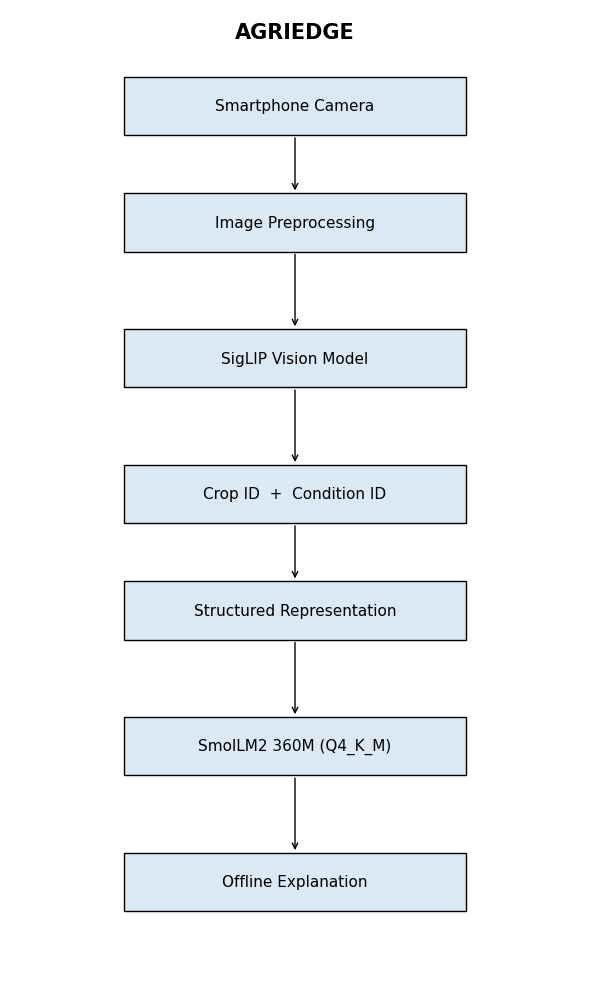

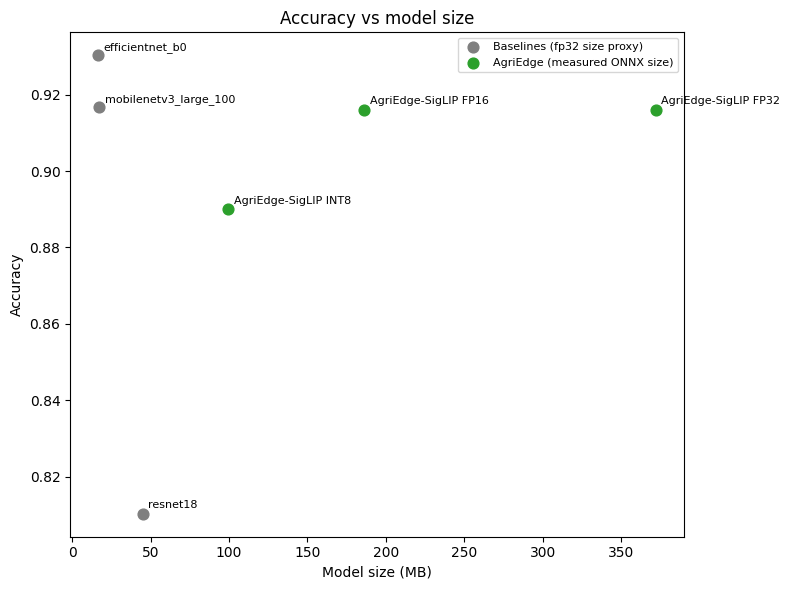

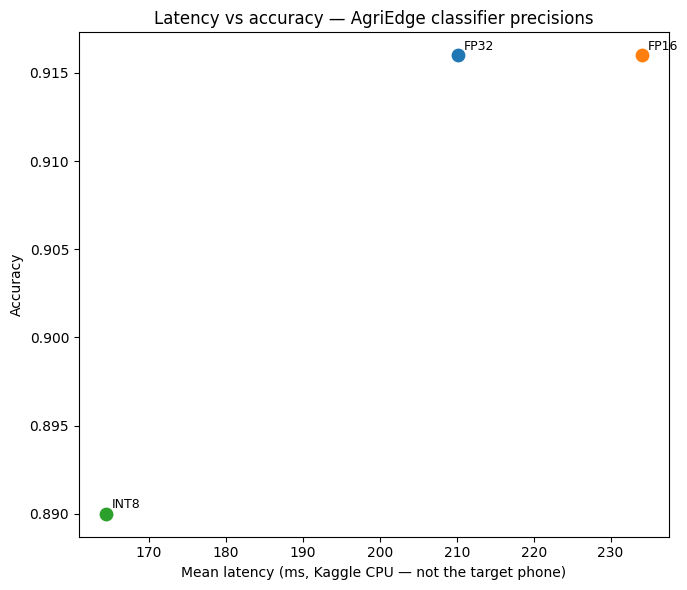

Saved: fig_architecture_diagram.png, fig_pareto_accuracy_vs_size.png, fig_pareto_latency_vs_accuracy.png

All results in: /kaggle/working/agriedge_bench/results
All figures in: /kaggle/working/agriedge_bench/figures


In [20]:
# =====================================================================
# CELL 12 — Final architecture diagram + Pareto plots (accuracy vs size,
# latency vs accuracy) across baselines + AgriEdge precision variants.
# FIXED: size_lookup KeyError (now defined correctly in Cell 9); AgriEdge FP32 was plotted
# twice (baseline_rows already contains an AgriEdge row); baselines vs AgriEdge now colour-coded;
# doesn't crash if Cell 10 (baselines) was skipped.
# =====================================================================
fig, ax = plt.subplots(figsize=(6, 10))
ax.axis("off")
boxes = [
    ("Smartphone Camera", 0.9), ("Image Preprocessing", 0.78), ("SigLIP Vision Model", 0.64),
    ("Crop ID  +  Condition ID", 0.5), ("Structured Representation", 0.38),
    ("SmolLM2 360M (Q4_K_M)", 0.24), ("Offline Explanation", 0.1),
]
for i, (label, y) in enumerate(boxes):
    ax.add_patch(plt.Rectangle((0.2, y - 0.03), 0.6, 0.06, fill=True, facecolor="#dbe9f4", edgecolor="black"))
    ax.text(0.5, y, label, ha="center", va="center", fontsize=11)
    if i < len(boxes) - 1:
        ax.annotate("", xy=(0.5, boxes[i+1][1] + 0.03), xytext=(0.5, y - 0.03),
                    arrowprops=dict(arrowstyle="->"))
ax.text(0.5, 0.97, "AGRIEDGE", ha="center", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_architecture_diagram.png", dpi=150)
plt.show()

# --- Pareto: accuracy vs size ---
# baselines: rough size proxy (fp32 params * 4 bytes); AgriEdge variants: measured ONNX sizes
baseline_points = []
if "baseline_rows" in globals():
    baseline_points = [(row["model"], row["params_m"] * 4, row["accuracy"])
                       for row in baseline_rows if row["accuracy"] and "AgriEdge" not in row["model"]]
else:
    print("[note] baseline_rows not found (Cell 10 not run) — plotting AgriEdge variants only.")
agri_points = [(f"AgriEdge-SigLIP {p}", size_lookup[p], clf_acc_by_precision[p]) for p in ["FP32", "FP16", "INT8"]]

fig, ax = plt.subplots(figsize=(8, 6))
for pts, color, label in [(baseline_points, "tab:gray", "Baselines (fp32 size proxy)"),
                          (agri_points, "tab:green", "AgriEdge (measured ONNX size)")]:
    for name, size_mb, accv in pts:
        ax.scatter(size_mb, accv, s=60, color=color, label=label)
        label = "_nolegend_"                        # one legend entry per group
        ax.annotate(name, (size_mb, accv), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Model size (MB)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs model size")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_pareto_accuracy_vs_size.png", dpi=150)
plt.show()

# --- Pareto: latency vs accuracy (classifier precisions only, latency measured) ---
fig, ax = plt.subplots(figsize=(7, 6))
for p in ["FP32", "FP16", "INT8"]:
    ax.scatter(latency_lookup[p], clf_acc_by_precision[p], s=80)
    ax.annotate(p, (latency_lookup[p], clf_acc_by_precision[p]), fontsize=9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean latency (ms, Kaggle CPU — not the target phone)")
ax.set_ylabel("Accuracy")
ax.set_title("Latency vs accuracy — AgriEdge classifier precisions")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_pareto_latency_vs_accuracy.png", dpi=150)
plt.show()

print("Saved: fig_architecture_diagram.png, fig_pareto_accuracy_vs_size.png, fig_pareto_latency_vs_accuracy.png")
print(f"\nAll results in: {RESULTS_DIR}")
print(f"All figures in: {FIG_DIR}")

In [21]:
# =====================================================================
# CELL 13 — Upload /kaggle/working/agriedge_bench to a Hugging Face repo.
# Uploads the deliverables (ONNX models, GGUF quantizations, result tables, figures) and
# SKIPS what shouldn't go on the Hub: the llama.cpp clone + build (multi-GB, someone else's
# repo), the dataset images (already in your agriedge-india-crops repo), and slm_fixed/
# (a local copy of the SLM weights already in agriedge-slm).
# Re-running is safe: unchanged files are de-duplicated by hash.
# =====================================================================
import os, fnmatch, time
from huggingface_hub import HfApi

HF_WRITE_TOKEN = "hf token"   # <-- paste a token with WRITE access
REPO_NAME = "agriedge-bench"                              # created under your account if missing
PRIVATE = True                                            # flip to False when you want it public
INCLUDE_DATASET_IMAGES = False                            # True = also upload datasets_sorted/ (large, duplicates the dataset repo)
DRY_RUN = False                                           # True = just print what would be uploaded
FOLDER = "/kaggle/working/agriedge_bench"

api = HfApi(token=HF_WRITE_TOKEN)
user = api.whoami()["name"]
repo_id = f"{user}/{REPO_NAME}"

IGNORE = ["llama.cpp/*", "datasets_sorted/*", "export/slm_fixed/*", "export/llama_gen.sh",
          "*/__pycache__/*", "*.pyc", ".cache/*", "*/.cache/*"]
if INCLUDE_DATASET_IMAGES:
    IGNORE.remove("datasets_sorted/*")

# ---------- README (dataset/model card) ----------
def _g(name, default="n/a"):
    return globals().get(name, default)

readme = f"""# AgriEdge — benchmark artifacts

Exported models and result tables from the AgriEdge research benchmark suite
(SigLIP crop/condition classifier + SmolLM2-360M explanation SLM).

Related repos: classifier `{_g('CLF_REPO')}` · SLM `{_g('SLM_REPO')}` · dataset `{_g('CROPS_DATASET_REPO')}`

## Contents
- `export/clf_fp32.onnx`, `clf_fp16.onnx`, `clf_int8.onnx` — classifier at three precisions
- `export/slm_*.gguf` — SLM at F16 / Q8_0 / Q5_K_M / Q4_K_M
- `results/*.csv` — every table (classifier metrics, size/latency, quantization ablation,
  baselines, backbone-depth ablation, end-to-end, SLM grounding)
- `figures/` — confusion matrices, distribution plots, Pareto plots, architecture diagram

## Read before citing any number
- Latency figures are from Kaggle CPU (4 threads), **not** the target phone hardware.
- Quantization-table classifier accuracies were evaluated on a subset of n={_g('N_ACC_EVAL')} test images
  (n_eval is recorded in the CSV); FP32 is the PyTorch model, FP16/INT8 are ONNX on CPU.
- Baselines and depth ablation were trained for {_g('BASELINE_EPOCHS')} / {_g('ABLATION_EPOCHS')} epochs, which is
  not an equal training budget to the AgriEdge classifier.
- SLM "grounding" is a heuristic string match (does the input crop/condition reappear in the answer);
  it is not human evaluation and cannot detect invented treatment advice.
"""
with open(f"{FOLDER}/README.md", "w") as f:
    f.write(readme)

# ---------- preview: what will / won't be uploaded ----------
def _size(p):
    try:
        return os.path.getsize(p)
    except OSError:
        return 0

rels = [os.path.relpath(os.path.join(d, fn), FOLDER) for d, _, fs in os.walk(FOLDER) for fn in fs]
keep = [r for r in rels if not any(fnmatch.fnmatch(r, p) for p in IGNORE)]
skip = [r for r in rels if r not in set(keep)]
keep_sizes = {r: _size(os.path.join(FOLDER, r)) for r in keep}
skip_total = sum(_size(os.path.join(FOLDER, r)) for r in skip)

print(f"Target repo : {repo_id}  ({'private' if PRIVATE else 'PUBLIC'})")
print(f"Uploading   : {len(keep)} files, {sum(keep_sizes.values())/1e6:,.0f} MB")
print(f"Skipping    : {len(skip)} files, {skip_total/1e6:,.0f} MB  (llama.cpp / dataset images / slm_fixed / caches)")
print("\nLargest files being uploaded:")
for r in sorted(keep, key=lambda r: -keep_sizes[r])[:10]:
    print(f"  {keep_sizes[r]/1e6:>9,.1f} MB  {r}")

# ---------- upload ----------
if DRY_RUN:
    print("\nDRY_RUN=True — nothing uploaded.")
else:
    api.create_repo(repo_id, repo_type="model", private=PRIVATE, exist_ok=True)
    t0 = time.time()
    try:
        api.upload_folder(folder_path=FOLDER, repo_id=repo_id, repo_type="model",
                          ignore_patterns=IGNORE,
                          commit_message="Add AgriEdge benchmark artifacts (ONNX, GGUF, results, figures)")
    except Exception as e:
        if any(code in str(e) for code in ("401", "403")):
            print("Upload rejected — the token needs WRITE permission for this account (Settings -> Access Tokens).")
        raise
    print(f"\nDone in {(time.time() - t0)/60:.1f} min -> https://huggingface.co/{repo_id}")

Target repo : vedantjadhav701/agriedge-bench  (private)
Uploading   : 26 files, 2,332 MB
Skipping    : 35621 files, 3,344 MB  (llama.cpp / dataset images / slm_fixed / caches)

Largest files being uploaded:
      725.6 MB  export/slm_f16.gguf
      386.4 MB  export/slm_q8_0.gguf
      372.1 MB  export/clf_fp32.onnx
      289.9 MB  export/slm_q5_k_m.gguf
      270.6 MB  export/slm_q4_k_m.gguf
      186.3 MB  export/clf_fp16.onnx
       99.6 MB  export/clf_int8.onnx
        0.4 MB  figures/fig_dataset_condition_distribution.png
        0.4 MB  figures/fig_confusion_condition.png
        0.1 MB  figures/fig_confusion_crop.png


/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:10908: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Done in 0.5 min -> https://huggingface.co/vedantjadhav701/agriedge-bench
